之前的模型（tf09, tf10）简单的只有一个输入，这次实验多输入。

值得注意的是输入输出格式相关的代码。

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

2025-05-25 17:01:38.341262: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-25 17:01:38.341982: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-25 17:01:38.344599: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-25 17:01:38.351641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748163698.363116   17972 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748163698.36

2.19.0
sys.version_info(major=3, minor=11, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.3
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
tensorflow 2.19.0
keras._tf_keras.keras 3.9.2


In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
from sklearn.model_selection import train_test_split

x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state = 7)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state = 11)
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)


(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

In [5]:
# 多输入，输入不再是同一个，wind和deep的输入不一样
input_wide = keras.layers.Input(shape=[5])
print(input_wide)
print(type(input_wide))
input_deep = keras.layers.Input(shape=[6])
print(input_deep)
print(type(input_deep))

hidden1 = keras.layers.Dense(30, activation='relu')(input_deep)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)
concat = keras.layers.concatenate([input_wide, hidden2])
output = keras.layers.Dense(1)(concat)
#这里是多输入
model = keras.models.Model(inputs = [input_wide, input_deep],
                           outputs = [output])

model.compile(loss="mean_squared_error", optimizer="sgd")
callbacks = [keras.callbacks.EarlyStopping(
    patience=5, min_delta=1e-3)]
model.summary()

<KerasTensor shape=(None, 5), dtype=float32, sparse=False, ragged=False, name=keras_tensor>
<class 'keras.src.backend.common.keras_tensor.KerasTensor'>
<KerasTensor shape=(None, 6), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>
<class 'keras.src.backend.common.keras_tensor.KerasTensor'>


2025-05-25 17:01:39.654246: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        210 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         36 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,176 (4.59 KB)

 Trainable params: 1,176 (4.59 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# wide选的是前面5列，deep选的是后面6列
x_train_scaled_wide = x_train_scaled[:, :5]  # 前 5 个
x_train_scaled_deep = x_train_scaled[:, 2:]  # 后 6 个特征（一共 8 个特征）
x_valid_scaled_wide = x_valid_scaled[:, :5]
x_valid_scaled_deep = x_valid_scaled[:, 2:]
x_test_scaled_wide = x_test_scaled[:, :5]
x_test_scaled_deep = x_test_scaled[:, 2:]
print(x_train_scaled_wide[:5])
print(x_train_scaled_deep[:5])
x_train_scaled_wide=x_train_scaled_wide[:10000]
x_train_scaled_deep=x_train_scaled_deep[:10000]
y_train=y_train[:10000]

[[ 0.80154431  0.27216142 -0.11624393 -0.20231151 -0.54305157]
 [-0.29807281  0.35226166 -0.10920508 -0.25055521 -0.03406402]
 [-0.03058829 -0.92934213  0.25962148 -0.00601274 -0.50040912]
 [ 1.90638325  0.51246213  0.4475828  -0.27672178 -0.63105833]
 [ 3.88017387 -0.92934213  1.29029867 -0.17269133 -0.22550141]]
[[-0.11624393 -0.20231151 -0.54305157 -0.02103962 -0.58976206 -0.08241846]
 [-0.10920508 -0.25055521 -0.03406402 -0.006034    1.08055484 -1.06113817]
 [ 0.25962148 -0.00601274 -0.50040912 -0.03077987  1.59844639 -1.81515182]
 [ 0.4475828  -0.27672178 -0.63105833 -0.07081147 -0.7064043   0.74649722]
 [ 1.29029867 -0.17269133 -0.22550141  0.0514101  -0.84637499  0.88631432]]


In [7]:
history = model.fit([x_train_scaled_wide, x_train_scaled_deep],
                    y_train,
                    validation_data = (
                        [x_valid_scaled_wide, x_valid_scaled_deep],
                        y_valid),
                    epochs = 100,
                    callbacks = callbacks)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6610 - val_loss: 0.7299
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 35.2217 - val_loss: 0.5506
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4782 - val_loss: 0.4545
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4387 - val_loss: 0.4463
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4304 - val_loss: 0.4364
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4190 - val_loss: 0.4704
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4116 - val_loss: 0.4268
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3984 - val_loss: 0.4087
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3973 - val_loss: 0.4147
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3863 - val_loss: 0.3994
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3905 - val_loss: 0.3920
Epoch 12/100
313/313 ━━━━━━━━━━━━━━━━━━━

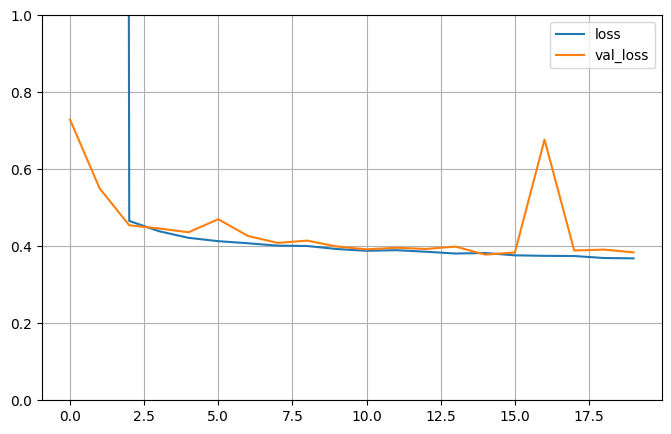

In [8]:
def plot_learning_curves(history):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.show()
plot_learning_curves(history)

In [9]:
# 可以看出比之前效果改进很多
model.evaluate([x_test_scaled_wide, x_test_scaled_deep], y_test, verbose=0)

0.3816407322883606